Saving iris.csv to iris.csv
✅ Iris Dataset Loaded Successfully!



,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129517 (\N{COMPASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


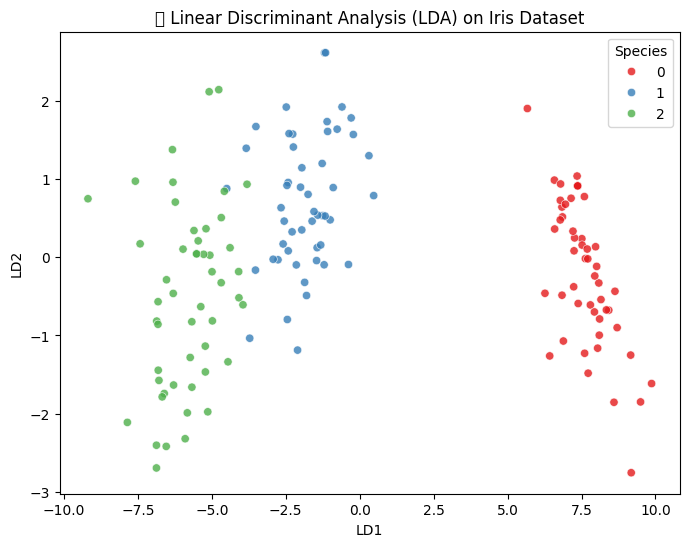

In [1]:
# =====================================
# 🧠 Linear Discriminant Analysis (LDA) on Iris Dataset
# =====================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from google.colab import files
import io

# Step 1️⃣: Upload CSV
uploaded = files.upload()
csv_filename = list(uploaded.keys())[0]

# Step 2️⃣: Load dataset
df = pd.read_csv(io.BytesIO(uploaded[csv_filename]))
print("✅ Iris Dataset Loaded Successfully!\n")
display(df.head())

# Step 3️⃣: Clean column names
df.columns = df.columns.str.strip()

# Step 4️⃣: Encode target column (species)
le = LabelEncoder()
df['species'] = le.fit_transform(df['species'])
# Setosa = 0, Versicolor = 1, Virginica = 2

# Step 5️⃣: Separate features and target
X = df.drop(columns=['species'])
y = df['species']

# Step 6️⃣: Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 7️⃣: Apply LDA
# Iris has 3 classes → max components = 3 - 1 = 2
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_scaled, y)

# Step 8️⃣: Create DataFrame for LDA results
lda_df = pd.DataFrame(X_lda, columns=['LD1', 'LD2'])
lda_df['Species'] = y

# Step 9️⃣: Visualize LDA (2D)
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=lda_df,
    x='LD1',
    y='LD2',
    hue='Species',
    palette='Set1',
    alpha=0.8
)

plt.title("🧭 Linear Discriminant Analysis (LDA) on Iris Dataset")
plt.xlabel("LD1")
plt.ylabel("LD2")
plt.legend(title="Species")
plt.show()
